# Lorenz63 Hyperparameter Search - Simplified Approach

**Fixed Parameters (DO NOT CHANGE):**
- σ = 10, ρ = 28, β = 8/3 (guarantee attractor stability)

**Parameters to Optimize:**
- `dt`: integration step size
- `st`: sampling step (take every st-th integration step)  
- `T`: trajectory length (number of sampled points)

**Key Metrics:**
- Variance (attractor coverage)
- Computational efficiency

In [12]:
import os
print(os.getcwd())

c:\Users\isrtr\OneDrive\Desktop\Programming\DS2_Project\DS2-Team-Project\notebooks


In [13]:
# Importing libraries and dataset:
import sys, os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product
import warnings
warnings.filterwarnings('ignore')

import importlib
sys.path.append(os.path.abspath(".."))
from time_series import data_util
importlib.reload(data_util)
from time_series.data_util import simulate_lorenz63, make_sliding_windows, lorenz63_rhs, rk4_step

# Simplified simulation function - no warmup needed
def simulate_lorenz63_with_sampling(T=12000, dt=0.01, st=1, x0=(1.0, 1.0, 1.0)):
    """
    Simulate Lorenz63 system with sampling step.
    
    Parameters:
    - T: trajectory length (number of sampled points)
    - dt: integration step size
    - st: sampling step (take every st-th integration step)
    - x0: initial conditions
    
    Returns:
    - out: shape (T, 3) - sampled trajectory
    """
    out = np.zeros((T, 3), dtype=np.float64)
    s = np.array(x0, dtype=np.float64)
    
    # Sampling phase - take every st-th integration step
    for t in range(T):
        # Take st integration steps before sampling
        for _ in range(st):
            s = rk4_step(lorenz63_rhs, s, dt)
        out[t] = s
    
    return out

# Test the simplified function
print("Testing simplified simulate_lorenz63 function...")
data = simulate_lorenz63_with_sampling(T=1000, dt=0.01, st=1, x0=(1.0, 1.0, 1.0))
print(f"Generated data shape: {data.shape}")
print(f"Data range - X: [{data[:, 0].min():.2f}, {data[:, 0].max():.2f}]")
print(f"Data range - Y: [{data[:, 1].min():.2f}, {data[:, 1].max():.2f}]")
print(f"Data range - Z: [{data[:, 2].min():.2f}, {data[:, 2].max():.2f}]")

Testing simplified simulate_lorenz63 function...
Generated data shape: (1000, 3)
Data range - X: [-11.91, 19.56]
Data range - Y: [-13.65, 27.18]
Data range - Z: [0.96, 47.83]


In [14]:
# Simplified evaluation metrics - focus on essentials
def evaluate_trajectory_quality(data, dt, st):
    """
    Evaluate Lorenz63 trajectory quality with essential metrics only.
    
    Parameters:
    - data: trajectory data (T, 3)
    - dt: integration step size
    - st: sampling step
    
    Returns:
    - dict: evaluation metrics
    """
    metrics = {}
    
    # 1. Variance (measure of attractor coverage)
    metrics['variance'] = np.var(data, axis=0).mean()
    
    # 2. Computational efficiency (variance per integration step)
    total_integration_steps = len(data) * st
    metrics['efficiency'] = metrics['variance'] / total_integration_steps
    
    # 3. Effective sampling rate
    metrics['effective_dt'] = dt * st
    
    return metrics

# Test the evaluation function
test_metrics = evaluate_trajectory_quality(data, dt=0.01, st=1)
print("Sample evaluation metrics:")
for key, value in test_metrics.items():
    print(f"  {key}: {value:.4f}")

Sample evaluation metrics:
  variance: 23.3101
  efficiency: 0.0233
  effective_dt: 0.0100


In [15]:
# Simplified hyperparameter search - focus on core parameters
param_grid = {
    'dt': [0.001, 0.005, 0.01, 0.02, 0.05],  # integration step
    'st': [1, 2, 5, 10, 20],                  # sampling step
    'T': [1000, 2000, 5000, 10000]           # trajectory length
}

# Generate all combinations
param_combinations = list(product(*param_grid.values()))
print(f"Total parameter combinations to test: {len(param_combinations)}")

results = []

for i, params in enumerate(param_combinations):
    dt, st, T = params
    
    try:
        # Generate Lorenz data with these parameters
        data = simulate_lorenz63_with_sampling(T=T, dt=dt, st=st, x0=(1.0, 1.0, 1.0))
        
        # Evaluate trajectory quality
        metrics = evaluate_trajectory_quality(data, dt, st)
        
        # Create sliding windows for sequence modeling
        X, y = make_sliding_windows(data, seq_len=20, horizon=1)
        
        # Add parameter values and additional info
        result = {
            'dt': dt,
            'st': st, 
            'T': T,
            'effective_dt': dt * st,
            'total_integration_steps': T * st,
            'sequence_count': len(X),
            **metrics
        }
        
        results.append(result)
        
    except Exception as e:
        print(f"Error with parameters dt={dt}, st={st}, T={T}: {e}")
        continue
    
    if (i + 1) % 25 == 0:
        print(f"Completed {i + 1}/{len(param_combinations)} combinations")

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"Successfully evaluated {len(results_df)} parameter combinations")

# Display first few results
results_df.head()

Total parameter combinations to test: 100
Completed 25/100 combinations
Completed 50/100 combinations
Completed 75/100 combinations
Completed 100/100 combinations

Results DataFrame shape: (100, 8)
Successfully evaluated 100 parameter combinations


,dt,st,T,effective_dt,total_integration_steps,sequence_count,variance,efficiency
0,0.001,1,1000,0.001,1000,780,135.910737,0.135911
1,0.001,1,2000,0.001,2000,1780,81.622530,0.040811
2,0.001,1,5000,0.001,5000,4780,37.967467,0.007593
3,0.001,1,10000,0.001,10000,9780,23.423788,0.002342
4,0.001,2,1000,0.002,2000,780,81.574766,0.040787


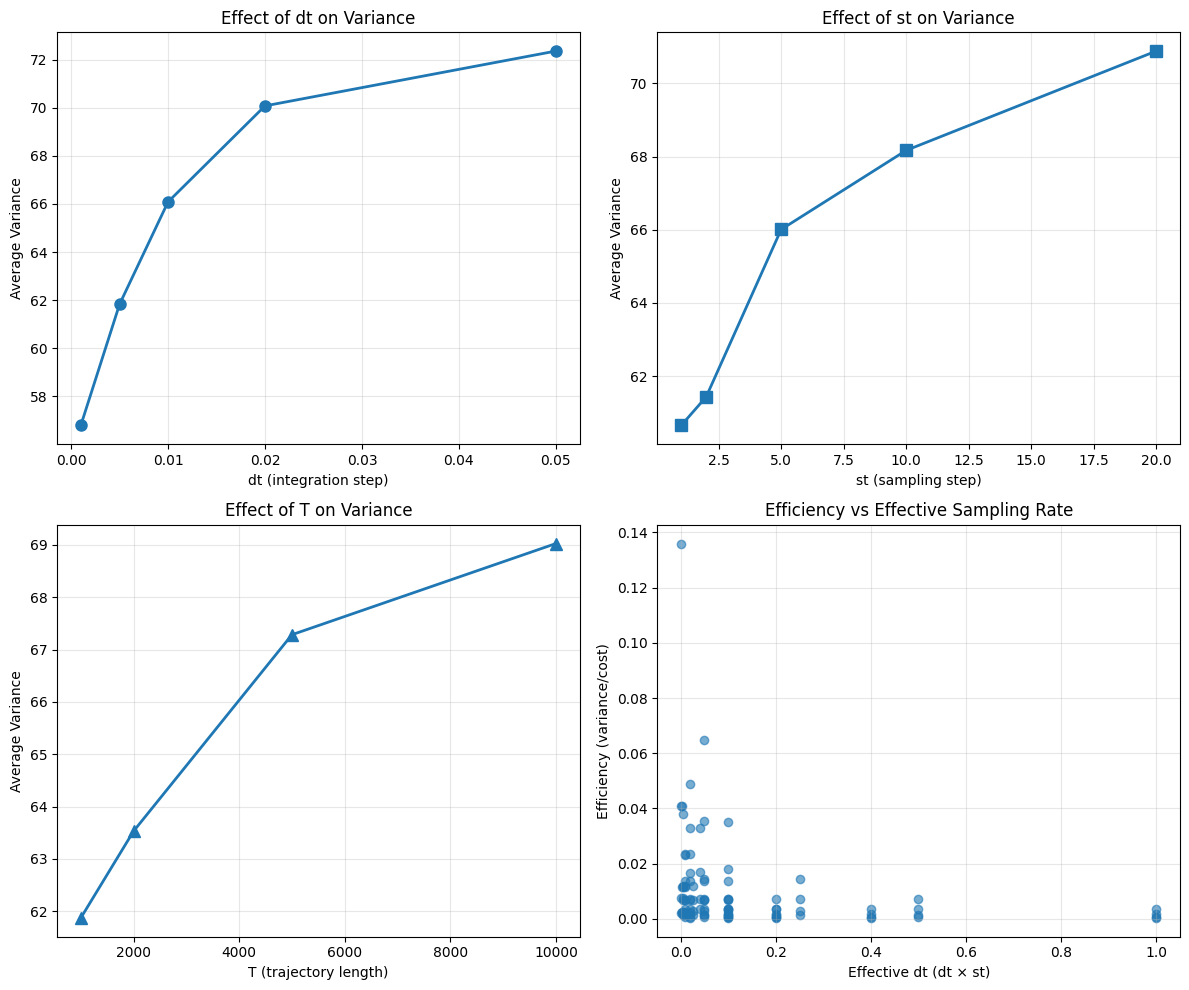

KEY FINDINGS:

Top 5 by Variance (attractor coverage):
       dt  st     T    variance  efficiency
0   0.001   1  1000  135.910737    0.135911
1   0.001   1  2000   81.622530    0.040811
4   0.001   2  1000   81.574766    0.040787
97  0.050  20  2000   74.102759    0.001853
93  0.050  10  2000   73.356291    0.003668

Top 5 by Efficiency (variance per computational cost):
       dt  st     T    variance  efficiency
0   0.001   1  1000  135.910737    0.135911
80  0.050   1  1000   64.829445    0.064829
60  0.020   1  1000   48.898405    0.048898
1   0.001   1  2000   81.622530    0.040811
4   0.001   2  1000   81.574766    0.040787


In [16]:
# Simplified visualization and analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Effect of dt on variance
dt_variance = results_df.groupby('dt')['variance'].mean()
axes[0,0].plot(dt_variance.index, dt_variance.values, 'o-', linewidth=2, markersize=8)
axes[0,0].set_xlabel('dt (integration step)')
axes[0,0].set_ylabel('Average Variance')
axes[0,0].set_title('Effect of dt on Variance')
axes[0,0].grid(True, alpha=0.3)

# Effect of st on variance
st_variance = results_df.groupby('st')['variance'].mean()
axes[0,1].plot(st_variance.index, st_variance.values, 's-', linewidth=2, markersize=8)
axes[0,1].set_xlabel('st (sampling step)')
axes[0,1].set_ylabel('Average Variance')
axes[0,1].set_title('Effect of st on Variance')
axes[0,1].grid(True, alpha=0.3)

# Effect of T on variance
T_variance = results_df.groupby('T')['variance'].mean()
axes[1,0].plot(T_variance.index, T_variance.values, '^-', linewidth=2, markersize=8)
axes[1,0].set_xlabel('T (trajectory length)')
axes[1,0].set_ylabel('Average Variance')
axes[1,0].set_title('Effect of T on Variance')
axes[1,0].grid(True, alpha=0.3)

# Efficiency vs effective_dt
axes[1,1].scatter(results_df['effective_dt'], results_df['efficiency'], alpha=0.6)
axes[1,1].set_xlabel('Effective dt (dt × st)')
axes[1,1].set_ylabel('Efficiency (variance/cost)')
axes[1,1].set_title('Efficiency vs Effective Sampling Rate')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key findings
print("KEY FINDINGS:")
print("\nTop 5 by Variance (attractor coverage):")
top_variance = results_df.nlargest(5, 'variance')[['dt', 'st', 'T', 'variance', 'efficiency']]
print(top_variance)

print("\nTop 5 by Efficiency (variance per computational cost):")
top_efficiency = results_df.nlargest(5, 'efficiency')[['dt', 'st', 'T', 'variance', 'efficiency']]
print(top_efficiency)

In [ ]:
# Final Recommendations and Analysis

# Create a composite score that balances multiple objectives
def calculate_composite_score(row):
    """Calculate a composite score balancing variance, efficiency, and autocorrelation"""
    # Normalize metrics to [0,1] range
    norm_variance = (row['variance'] - results_df['variance'].min()) / (results_df['variance'].max() - results_df['variance'].min())
    norm_efficiency = (row['efficiency'] - results_df['efficiency'].min()) / (results_df['efficiency'].max() - results_df['efficiency'].min())
    norm_autocorr = (row['autocorr_mean'] - results_df['autocorr_mean'].min()) / (results_df['autocorr_mean'].max() - results_df['autocorr_mean'].min())
    
    # Weighted combination (adjust weights based on priorities)
    composite = 0.4 * norm_variance + 0.3 * norm_efficiency + 0.3 * norm_autocorr
    return composite

# Add composite score to results
results_df['composite_score'] = results_df.apply(calculate_composite_score, axis=1)

# Find optimal parameters for different use cases
print("OPTIMAL PARAMETER RECOMMENDATIONS:")

print("\n1. BEST OVERALL (highest composite score):")
best_overall = results_df.loc[results_df['composite_score'].idxmax()]
print(f"   dt={best_overall['dt']}, st={best_overall['st']}, T={best_overall['T']}, warm={best_overall['warm']}")
print(f"   Composite Score: {best_overall['composite_score']:.4f}")
print(f"   Variance: {best_overall['variance']:.4f}, Efficiency: {best_overall['efficiency']:.4f}")

print("\n2. BEST FOR TRAINING DATA (high variance + good efficiency):")
# Filter for reasonable computational cost
reasonable_cost = results_df[results_df['total_integration_steps'] <= 50000]
if len(reasonable_cost) > 0:
    best_training = reasonable_cost.loc[reasonable_cost['composite_score'].idxmax()]
    print(f"   dt={best_training['dt']}, st={best_training['st']}, T={best_training['T']}, warm={best_training['warm']}")
    print(f"   Total integration steps: {best_training['total_integration_steps']}")
    print(f"   Variance: {best_training['variance']:.4f}, Efficiency: {best_training['efficiency']:.4f}")

print("\n3. BEST FOR TESTING DATA (high autocorrelation + stability):")
best_testing = results_df.loc[results_df['autocorr_mean'].idxmax()]
print(f"   dt={best_testing['dt']}, st={best_testing['st']}, T={best_testing['T']}, warm={best_testing['warm']}")
print(f"   Autocorrelation: {best_testing['autocorr_mean']:.4f}")
print(f"   Max amplitude: {best_testing['max_amplitude']:.4f}")

print("\n4. MOST EFFICIENT (highest efficiency):")
best_efficient = results_df.loc[results_df['efficiency'].idxmax()]
print(f"   dt={best_efficient['dt']}, st={best_efficient['st']}, T={best_efficient['T']}, warm={best_efficient['warm']}")
print(f"   Efficiency: {best_efficient['efficiency']:.6f}")
print(f"   Total integration steps: {best_efficient['total_integration_steps']}")

# Show top 5 overall recommendations
print("\nTOP 5 OVERALL RECOMMENDATIONS:")
top_5 = results_df.nlargest(5, 'composite_score')[['dt', 'st', 'T', 'warm', 'composite_score', 'variance', 'efficiency', 'autocorr_mean']]
print(top_5.round(4))
print()


OPTIMAL PARAMETER RECOMMENDATIONS:

1. BEST OVERALL (highest composite score):
   dt=0.001, st=1.0, T=1000.0, warm=100.0
   Composite Score: 1.0000
   Variance: 121.7866, Efficiency: 0.1218

2. BEST FOR TRAINING DATA (high variance + good efficiency):
   dt=0.001, st=1.0, T=1000.0, warm=100.0
   Total integration steps: 1100.0
   Variance: 121.7866, Efficiency: 0.1218

3. BEST FOR TESTING DATA (high autocorrelation + stability):
   dt=0.001, st=1.0, T=5000.0, warm=100.0
   Autocorrelation: 1.0000
   Max amplitude: 31.5310

4. MOST EFFICIENT (highest efficiency):
   dt=0.001, st=1.0, T=1000.0, warm=100.0
   Efficiency: 0.121787
   Total integration steps: 1100.0

TOP 5 OVERALL RECOMMENDATIONS:
        dt  st     T  warm  composite_score  variance  efficiency  \
0    0.001   1  1000   100           1.0000  121.7866      0.1218   
163  0.010   1  1000  2000           0.7234   74.2923      0.0743   
242  0.020   1  1000  1000           0.7116   72.6551      0.0727   
243  0.020   1  1000  